# Import libraries for Life Expectancy df cleaning

In [607]:
import pandas as pd
import numpy as np
from thefuzz import process

import statsmodels.api as sm

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

import seaborn as sns

# Load project datasets

The following datasets are imported to replace data in original Life Expectancy dataset to be used as template

## Import project template dataframe as life_expectancy

In [608]:
# Successfully loaded the Life_Expectancy_Data.csv as a Pandas dataframe in variable life_expectancy_raw, and copied dataframe to new variable life_expectancy.

life_expectancy_raw = pd.read_csv('../Datasets/Raw_datasets/Life_Expectancy_Data.csv')
life_expectancy = life_expectancy_raw.copy()


## Import and tidy WHO datasets

### Adult mortality rate

In [609]:
# Successfully import adult mortality rate data from WHO data repository as variable adult_mortality

adult_mortality_rate_csv = pd.read_csv('../Datasets/Raw_datasets/WHO/Adult_Mortality_rate/Adult_mortality_rate_who.csv')
adult_mortality_cut = adult_mortality_rate_csv[['Location', 'Period', 'Dim1', 'FactValueNumeric']]

# Change column names for usability
adult_mortality_raw = adult_mortality_cut.rename(columns={
    'Location' : 'country',
    'Period' : 'year',
    'Dim1' : 'sex_classification',
    'FactValueNumeric' : 'adult_mortality'
})

adult_mortality_raw['country'] = adult_mortality_raw['country'].astype('string')

countries_to_modify = ['Cote d\'Ivoire', 'Netherlands (Kingdom of the)', 'North Macedonia', 'Türkiye']
country_modification = ['Côte d\'Ivoire', 'Netherlands', 'The former Yugoslav republic of Macedonia', 'Turkey']
for i in range(len(countries_to_modify)):
    adult_mortality_raw['country'] = adult_mortality_raw['country'].replace(countries_to_modify[i], country_modification[i])

# Filter 'Both sexes' column for years 2000 to 2015
adult_mortality_both_sexes = adult_mortality_raw[(adult_mortality_raw['sex_classification'] == 'Both sexes') & (adult_mortality_raw['year'].apply(lambda x: 2000 <= x <= 2015))].sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)
who_adult_mortality_total = adult_mortality_both_sexes.drop(columns=['sex_classification'])


### Child deaths per 1000 births

In [610]:
# Successfully import child deaths per 1000 births data from WHO data repository as variable infant_deaths and under_5_deaths
child_deaths_per_1000_csv= pd.read_csv('../Datasets/Raw_datasets/WHO/Child_deaths_per_1000_births/child_deaths_per_1000_births.csv')

# Filter usable columns and renaming for usability
child_deaths_slice_raw = child_deaths_per_1000_csv[['Location', 'Period', 'Dim1', 'Dim2', 'Value']]
child_mortality_full = child_deaths_slice_raw.rename(columns={
    'Location' : 'country',
    'Period' : 'year',
    'Dim1' : 'age_classification',
    'Dim2' : 'cause',
    'Value' : 'deaths'
})  


#### Infant mortality

In [611]:
infant_mortality_all_causes_new = child_mortality_full[(child_mortality_full['age_classification'] == '0-27 days') & (child_mortality_full['year'].apply(lambda x: 2000 <= x <= 2015))].sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)
infant_mortality_all_causes = infant_mortality_all_causes_new.pivot(index=['country', 'year'], columns=['cause'], values=['deaths']).sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=False)
infant_mortality_all_causes.columns = [
    col[1] if col[1] else col[0] for col in infant_mortality_all_causes.columns]
print(infant_mortality_all_causes.columns)
infant_mortality_all_causes = infant_mortality_all_causes.rename(columns={
    'Acute lower respiratory infections' : 'acute_lower_respiratory_infections',
    'Birth asphyxia and birth trauma' : 'birth_asphyxia_and_birth_trauma',
    'Congenital anomalies' : 'congenital_anomalies',
    'Diarrhoeal diseases' : 'diarrhoeal_diseases',
    'HIV/AIDS' : 'hiv_aids',
    'Injuries' : 'injuries',
    'Malaria' : 'malaria',
    'Measles' : 'measles',
    'Meningitis/encephalitis' : 'meningitis_and_or_encephalitis',
    'Other communicable, perinatal and nutritional conditions' : 'other_communicable_perinatal_and_nutritional_conditions',
    'Other noncommunicable diseases' : 'other_noncommunicable_diseases',
    'Prematurity' : 'prematurity',
    'Sepsis and other infectious conditions of the newborn' : 'sepsis_and_other_infectious_conditions',
    'Tetanus' : 'tetanus'        
})

infant_mortality_all_causes['country'] = infant_mortality_all_causes['country'].astype('string')

countries_to_modify = ['Cote d\'Ivoire', 'Netherlands (Kingdom of the)', 'North Macedonia', 'Türkiye']
country_modification = ['Côte d\'Ivoire', 'Netherlands', 'The former Yugoslav republic of Macedonia', 'Turkey']
for i in range(len(countries_to_modify)):
    infant_mortality_all_causes['country'] = infant_mortality_all_causes['country'].replace(countries_to_modify[i], country_modification[i])

Index(['country', 'year', 'Acute lower respiratory infections',
       'Birth asphyxia and birth trauma', 'Congenital anomalies',
       'Diarrhoeal diseases', 'HIV/AIDS', 'Injuries', 'Malaria', 'Measles',
       'Meningitis/encephalitis',
       'Other communicable, perinatal and nutritional conditions',
       'Other noncommunicable diseases', 'Prematurity',
       'Sepsis and other infectious conditions of the newborn', 'Tetanus'],
      dtype='object')


#### Under-5 mortality

In [612]:
under_5_all_causes = child_mortality_full[(child_mortality_full['age_classification'] == '1-59 months') & (child_mortality_full['year'].apply(lambda x: 2000 <= x <= 2015))].sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)
under_5_all_causes = under_5_all_causes.pivot(index=['country', 'year'], columns=['cause'], values=['deaths']).sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=False)
under_5_all_causes.columns = [
    col[1] if col[1] else col[0] for col in under_5_all_causes.columns]
under_5_mortality_all_causes = under_5_all_causes.rename(columns={
    'Acute lower respiratory infections' : 'acute_lower_respiratory_infections',
    'Birth asphyxia and birth trauma' : 'birth_asphyxia_and_birth_trauma',
    'Congenital anomalies' : 'congenital_anomalies',
    'Diarrhoeal diseases' : 'diarrhoeal_diseases',
    'HIV/AIDS' : 'hiv_aids',
    'Injuries' : 'injuries',
    'Malaria' : 'malaria',
    'Measles' : 'measles',
    'Meningitis/encephalitis' : 'meningitis_and_or_encephalitis',
    'Other communicable, perinatal and nutritional conditions' : 'other_communicable_perinatal_and_nutritional_conditions',
    'Other noncommunicable diseases' : 'other_noncommunicable_diseases',
    'Prematurity' : 'prematurity',
    'Sepsis and other infectious conditions of the newborn' : 'sepsis_and_other_infectious_conditions',
    'Tetanus' : 'tetanus'  
    })

under_5_mortality_all_causes['country'] = under_5_mortality_all_causes['country'].astype('string')

countries_to_modify = ['Cote d\'Ivoire', 'Netherlands (Kingdom of the)', 'North Macedonia', 'Türkiye']
country_modification = ['Côte d\'Ivoire', 'Netherlands', 'The former Yugoslav republic of Macedonia', 'Turkey']
for i in range(len(countries_to_modify)):
    under_5_mortality_all_causes['country'] = under_5_mortality_all_causes['country'].replace(countries_to_modify[i], country_modification[i])

## Import and tidy World Bank datasets

### Population by country

In [613]:
# Successfully loaded the world_bank_population.csv as a Pandas dataframe in variable world_population.

world_population = pd.read_csv('../Datasets/Raw_datasets/World_Bank/Population/world_bank_population.csv', on_bad_lines='skip')

### GDP per capita

In [614]:
# Successfully loaded the world_bank_gdp_1960_to_2023.csv as a Pandas dataframe in variable wb_gdp.
wb_gdp = pd.read_csv('../Datasets/Raw_datasets/World_Bank/GDP/world_bank_gdp_1960_to_2023.csv')

wb_gdp_2000_to_2015 = wb_gdp[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]
wb_gdp_drop_na = wb_gdp_2000_to_2015.dropna().reset_index(drop=True)

### Health expenditure percentage

In [615]:
# Successfully loaded the world_bank_health_expend_percentage.csv as a Pandas dataframe in variable wb_health_exp_perc.
wb_health_exp_perc = pd.read_csv('../Datasets/Raw_datasets/World_Bank/Health_Expenditure/world_bank_health_expend_percentage.csv')
wb_exp_perc_2000_to_2015 = wb_health_exp_perc[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]
wb_health_exp_perc_dropna = wb_exp_perc_2000_to_2015.dropna().reset_index(drop=True)

### Life expectancy

In [616]:
# Successfully loaded the life_expectancy_from_world_bank.csv as a Pandas dataframe in variable world_population.
world_life_expectancy= pd.read_csv('../Datasets/Raw_datasets/World_Bank/Life_expectancy/life_expectancy_from_world_bank.csv')


### Education expenditure

In [617]:
# Successfully loaded the World_Bank_education_expenditure_gdp_percentage.csv as a Pandas dataframe in variable world_population.
world_education_expenditure= pd.read_csv('../Datasets/Raw_datasets/World_Bank/Education_expenditure/World_Bank_education_expenditure_gdp_percentage.csv')



### Unemployment total percentage

In [618]:
# Successfully loaded the world_bank_unemployment_total.csv as a Pandas dataframe in variable unemployment_total.
world_unemployment_total = pd.read_csv('../Datasets/Raw_datasets/World_Bank/unemployment_total/world_bank_unemployment_total.csv')


### Alcohol consumption

In [619]:
# Successfully loaded the Alchohol_consumption/World_Alchohol_consumption_liters.csv as a Pandas dataframe in variable unemployment_total.
world_alcohol_consumption = pd.read_csv('../Datasets/Raw_datasets/World_Bank/Alchohol_consumption/World_Alchohol_consumption_liters.csv')


### Government health expenditure

In [620]:
# Successfully loaded the world_gov_health_expenditure_percentage.csv as a Pandas dataframe in variable world_total_expenditure_gov.
world_total_expenditure_gov = pd.read_csv('../Datasets/Raw_datasets/World_Bank/Government_Health_Expenditure/World_Gov_health_expenditure_percentage.csv')


## Our World in Data

### BMI

In [621]:
# Successfully loaded the mean_body_mass_index_bmi_in_adult_males.csv as a Pandas dataframe in variable world_in_data_bmi.
world_in_data_bmi= pd.read_csv('../Datasets/Raw_datasets/Our_World_in_Data/bmi/Male/mean_body_mass_index_bmi_in_adult_males.csv')

# Successfully loaded the mean_body_mass_index_bmi_in_adult_women.csv as a Pandas dataframe in variable world_in_data_bmi_female.
world_in_data_bmi_female = pd.read_csv('../Datasets/Raw_datasets/Our_World_in_Data/bmi/Female/mean_body_mass_index_bmi_in_adult_women.csv')

# Tidying template - life_expectancy df:

Renaming all the columns to more usable variables. The columns are all either of type integer, float or object, making it suitbale for visualization

In [622]:
print(life_expectancy.columns)

life_expectancy.rename(columns= {
    'Country' : 'country',
    'Year' : 'year',
    'Status' : 'status',
    'Life expectancy ' : 'life_expectancy',
    'Adult Mortality' : 'adult_mortality',
    'infant deaths' : 'infant_deaths',
    'Alcohol' : 'alcohol',
    'percentage expenditure' : 'percentage_expenditure',
    'Hepatitis B' : 'hepatitis_b',
    'Measles ' : 'measles',
    ' BMI ' : 'bmi',
    'under-five deaths ' : 'under_five_deaths', 
    'Polio' : 'polio',
    'Total expenditure' : 'total_expenditure',
    'Diphtheria ' : 'diphtheria',
    ' HIV/AIDS' : 'hiv_aids',
    'GDP' : 'gdp',
    'Population' : 'population',
    ' thinness  1-19 years' : 'thinness_1_to_19_years',
    ' thinness 5-9 years' : 'thinness_5_to_9_years',
    'Income composition of resources' : 'income_composition_of_resources',
    'Schooling' : 'schooling'
}, inplace=True)

life_expectancy['country'] = life_expectancy['country'].astype('string')

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


Finding rows in life_expectancy dataframe of countries which only have one entry (particularly '2013') and deleting those rows.

In [623]:
# Create a dictionary of unique countries with their value counts
unique_countries = dict(life_expectancy.country.value_counts())

# Creat an array of all the countries which appears more than once
valid_countries = np.array([key for key, value in list(unique_countries.items()) if value > 1])

# Modifying countries in 'country' column so all countries which only appear once becomes a missing value.
# Dropping all rows where a nan value occurs in 'country' column
life_exp_valid_countries = life_expectancy.copy()
life_exp_valid_countries['country'] = life_exp_valid_countries['country'].apply(lambda x: x if x in valid_countries else np.nan)
life_exp_valid_countries = life_exp_valid_countries.dropna(subset=['country'])


# Preparing imported datasets for life_expectancy df merge

## World Bank datasets

Working with World Bank Population data and cleaning:
1.  Creating list of unique countries in both World Bank and Life Expectancy df
2.  Creating modification list of uniques life expectancy countries for removal if present in world bank gdp df. All world bank countries are named exactly the same.
3.  Using thefuzz.process lib matches can be found to be updated and stored to matches list for updating
4.  Some countries which were not correctly matched could be manually recorded and stored in new_matches_list
5.  All countries in world bank population are replaced with values matching that of life expectancy
6.  Checking countries not the same in both dfs for process assurance
7.  Three Countries appearing in life expectancy but not population df are dropped
8.  Format population df to only contain data for appropriate years
9.  As World Bank uses the same names for countries in their datasets, World Banks's GDP df could be used for modifying country values for all World Bank dfs.


#### Modifying 'country' column values to coincide with life expectancy 'country' values

In [624]:
# Create lists of unique countries in both world bank gdp dataframe and Life Expectancy dataframe for comparison
country_list_wb = list(wb_gdp_2000_to_2015['Country Name'])
country_list_le = list(life_expectancy['country'][life_expectancy['year'] == 2000])

# Finding countries from Life Expectancy df which are not in same format as in world bank gdp dataframe
countries_to_modify = country_list_le.copy()
for country in country_list_le:
    if country in country_list_wb:
        countries_to_modify.remove(country)

# Finding matches in world bank population dataframe using process.extractOne funcion from thefuzz lib for renaming to country names in Life Expectancy df 
# - First string is country for Life Exp df
# - second is world bank population df, 
# - third is match level percentage 
matches = []
for country in countries_to_modify:
    match = process.extractOne(country, country_list_wb, score_cutoff=80)
    if match:
        matches.append((country, match[0], match[1]))

# Retrieving all info from thefuzz output data and listing it to prepare for manual changes
new_matches_list = []
for tuple in matches:
    new_matches_list.append(list(tuple))

# Manually changing new matches list for values which was not matched correctly using thefuzz function
new_matches_list[4][1] = "Korea, Dem. People's Rep."
new_matches_list[5][1] = 'Congo, Rep.'
new_matches_list[8][1] = 'Iran, Islamic Rep.'
new_matches_list[11][1] = 'Korea, Rep.'
new_matches_list[13][1] = 'St. Lucia'
new_matches_list[15][1] = 'North Macedonia'
new_matches_list.append(['Turkey', 'Turkiye'])
new_matches_list.append(['Slovakia', 'Slovak Republic'])

# Iterating over matches and replacing old country names in world bank pop df with synchronized names occurring in life expectancy df
world_pop_cleaned = world_population.copy()
for world_pop_country in new_matches_list:
    world_pop_cleaned['Country Name'] = world_pop_cleaned['Country Name'].replace(world_pop_country[1], world_pop_country[0])


# Checking for countries occurring in life expectancy df and not in world bank pop df
country_list_wb_new = list(world_pop_cleaned['Country Name'])
country_list_le_1 = list(life_expectancy['country'][life_expectancy['year'] == 2000])

# Cross checking countries from life_expectancy df which are not present in World Bank datasets
countries_cross_check = []
for country in country_list_le_1:
    if country not in country_list_wb_new:
        countries_cross_check.append(country)


# Dropping 'Dominican Republic', 'Kyrgyzstan' and 'Swaziland' from life_expectancy df
life_exp_clean = life_exp_valid_countries.drop(life_exp_valid_countries[(life_exp_valid_countries['country'] == countries_cross_check[0]) | (life_exp_valid_countries['country'] == countries_cross_check[1]) | (life_exp_valid_countries['country'] == countries_cross_check[2])].index).reset_index(drop=True)
life_exp_clean = life_exp_clean.sort_values(by=['country', 'year'], ascending=[True, False])
life_exp_clean_countries = life_exp_clean['country'].unique()

# Finding countries in life expectancy df which needs to be filled with population values from world bank population df
life_exp_pop_nan = life_exp_clean[life_exp_clean['gdp'].isna()]
countries_to_fill = life_exp_pop_nan['country'].unique()

# formatting world bank pop df to only include population values relavent to year 2000 to 2015 from life expectancy df 
world_pop_2000_to_2015 = world_pop_cleaned[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]



### Population

Creating function for generating World Bank dataframes separately, by year and in the same format as life expectancy df, to be concattenated and then joined

In [625]:
# Finding all values for countries listed in life_expectancy_clean and formatting dataframe to be in same format for later concattenation
life_exp_clean_countries = life_exp_clean['country'].unique()
wb_pop_drop_na = world_pop_2000_to_2015.copy()
wb_pop_drop_na = wb_pop_drop_na.dropna().reset_index(drop=True)

def modified_wb_pop_by_year(year_column, target_column, columns_to_display):
    wb_pop_year = wb_pop_drop_na.copy()
    wb_pop_year = wb_pop_year[['Country Name', year_column]]
    wb_pop_year_modified = wb_pop_year.copy()
    
    year_list = []
    for x in range(0, 265):
        year_list.append(int(year_column))
    wb_pop_year_modified['year'] = year_list
    
    wb_pop_year_modified.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_pop_year_modified = wb_pop_year_modified[columns_to_display]

    # Create df to only display countries in wb_pop_year_modified which occur in life_exp_clean_countries
    wb_pop_year_modified['country'] = wb_pop_year_modified['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA).reset_index(drop=True)
    wb_pop_year_modified = wb_pop_year_modified.dropna(subset=['country']).reset_index(drop=True)
    return wb_pop_year_modified



Concattenating all wb_gdp_year_modified to create and reorder dataframe to coincide with life expectancy df
1.  Using modified_wb_pop_by_year function dfs are generated by year
2.  All generated dfs are concattenated
3.  Concattenated df is correctly sorted
4.  Merging life_expectancy_clean and wb_pop_sorted so population in the former is overridden by population in the latter

In [626]:
# Running modified_wb_pop_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_pop_2000_modified = modified_wb_pop_by_year('2000', 'population', ['country', 'year', 'population'])
wb_pop_2001_modified = modified_wb_pop_by_year('2001', 'population', ['country', 'year', 'population'])
wb_pop_2002_modified = modified_wb_pop_by_year('2002', 'population', ['country', 'year', 'population'])
wb_pop_2003_modified = modified_wb_pop_by_year('2003', 'population', ['country', 'year', 'population'])
wb_pop_2004_modified = modified_wb_pop_by_year('2004', 'population', ['country', 'year', 'population'])
wb_pop_2005_modified = modified_wb_pop_by_year('2005', 'population', ['country', 'year', 'population'])
wb_pop_2006_modified = modified_wb_pop_by_year('2006', 'population', ['country', 'year', 'population'])
wb_pop_2007_modified = modified_wb_pop_by_year('2007', 'population', ['country', 'year', 'population'])
wb_pop_2008_modified = modified_wb_pop_by_year('2008', 'population', ['country', 'year', 'population'])
wb_pop_2009_modified = modified_wb_pop_by_year('2009', 'population', ['country', 'year', 'population'])
wb_pop_2010_modified = modified_wb_pop_by_year('2010', 'population', ['country', 'year', 'population'])
wb_pop_2011_modified = modified_wb_pop_by_year('2011', 'population', ['country', 'year', 'population'])
wb_pop_2012_modified = modified_wb_pop_by_year('2012', 'population', ['country', 'year', 'population'])
wb_pop_2013_modified = modified_wb_pop_by_year('2013', 'population', ['country', 'year', 'population'])
wb_pop_2014_modified = modified_wb_pop_by_year('2014', 'population', ['country', 'year', 'population'])
wb_pop_2015_modified = modified_wb_pop_by_year('2015', 'population', ['country', 'year', 'population'])

# Concattenating population dfs for all years
wb_pop_2000_to_2015_modified = pd.concat([wb_pop_2000_modified, wb_pop_2001_modified, wb_pop_2002_modified, wb_pop_2003_modified, wb_pop_2004_modified, 
                                          wb_pop_2005_modified, wb_pop_2006_modified, wb_pop_2007_modified, wb_pop_2008_modified, wb_pop_2009_modified, 
                                          wb_pop_2010_modified, wb_pop_2011_modified, wb_pop_2012_modified, wb_pop_2013_modified, wb_pop_2014_modified, 
                                          wb_pop_2015_modified])

# Sorting new population dataframe in same format as Life Expectancy df
wb_pop_sorted = wb_pop_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

wb_pop_array = wb_pop_sorted['population']
life_exp_clean['population'] = wb_pop_array
print(life_exp_clean['country'].nunique())

180


### GDP

Modifying World Bank's gdp data using variables created whilst cleaning Population dataframe - Same procedure followed as modifying population to find yearly df (2000 - 2015)
1.  new_matches_list contains all the country names which needs to be replaced

In [627]:
# Iterating over matches and replacing old country names in world bank gdp df with synchronized names occurring in life expectancy df
world_gdp_cleaned = wb_gdp.copy()
for world_gdp_country in new_matches_list:
    world_gdp_cleaned['Country Name'] = world_gdp_cleaned['Country Name'].replace(world_gdp_country[1], world_gdp_country[0])


# formatting world bank gdp df to only include gdp values relavent to year 2000 to 2015 from life expectancy df 
world_gdp_2000_to_2015 = world_gdp_cleaned[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in life_expectancy_clean and formatting dataframe to be in same format for later concattenation
life_exp_clean_countries = life_exp_clean['country'].unique()
wb_gdp_drop_na = world_gdp_2000_to_2015.copy()
wb_gdp_drop_na = wb_gdp_drop_na.dropna().reset_index(drop=True)


# Create a function to clean gdp df for each year to be concattenated and joined with life_expectancy df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'gdp']

def modified_wb_gdp_by_year(year_column, target_column, columns_to_display):
    wb_gdp_year = wb_gdp_drop_na.copy()
    #print(wb_gdp_year)
    wb_gdp_year = wb_gdp_year[['Country Name', year_column]]
    wb_gdp_year_modified = wb_gdp_year.copy()
    
    year_list = []
    for x in range(0, 248):
        year_list.append(int(year_column))
    wb_gdp_year_modified['year'] = year_list
    
    wb_gdp_year_modified.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_gdp_year_modified = wb_gdp_year_modified[columns_to_display]

    # Create df to only display countries in wb_gdp_year_modified which occur in life_exp_clean_countries
    wb_gdp_year_modified['country'] = wb_gdp_year_modified['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA).reset_index(drop=True)
    wb_gdp_year_modified = wb_gdp_year_modified.dropna(subset=['country']).reset_index(drop=True)
    return wb_gdp_year_modified

# Running modified_wb_gdp_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectancy df
wb_gdp_2000_modified = modified_wb_gdp_by_year('2000', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2001_modified = modified_wb_gdp_by_year('2001', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2002_modified = modified_wb_gdp_by_year('2002', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2003_modified = modified_wb_gdp_by_year('2003', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2004_modified = modified_wb_gdp_by_year('2004', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2005_modified = modified_wb_gdp_by_year('2005', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2006_modified = modified_wb_gdp_by_year('2006', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2007_modified = modified_wb_gdp_by_year('2007', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2008_modified = modified_wb_gdp_by_year('2008', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2009_modified = modified_wb_gdp_by_year('2009', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2010_modified = modified_wb_gdp_by_year('2010', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2011_modified = modified_wb_gdp_by_year('2011', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2012_modified = modified_wb_gdp_by_year('2012', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2013_modified = modified_wb_gdp_by_year('2013', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2014_modified = modified_wb_gdp_by_year('2014', 'gdp', ['country', 'year', 'gdp'])
wb_gdp_2015_modified = modified_wb_gdp_by_year('2015', 'gdp', ['country', 'year', 'gdp'])


Concattenate dataframes created with modified_wb_gdp_by_year function. Finding unique countries in life_expectancy_clean df which do not occur in World Bank cleaned GDP df and removing them in order to eliminate missing values in the Life Expectancy 'gdp'column.

In [628]:
wb_gdp_2000_to_2015_modified = pd.concat([wb_gdp_2000_modified, wb_gdp_2001_modified, wb_gdp_2002_modified, wb_gdp_2003_modified, wb_gdp_2004_modified, 
                                          wb_gdp_2005_modified, wb_gdp_2006_modified, wb_gdp_2007_modified, wb_gdp_2008_modified, wb_gdp_2009_modified, 
                                          wb_gdp_2010_modified, wb_gdp_2011_modified, wb_gdp_2012_modified, wb_gdp_2013_modified, wb_gdp_2014_modified, 
                                          wb_gdp_2015_modified])
wb_gdp_sorted = wb_gdp_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# Countries in life expectancy df and not in gdp df are dropped
wb_gdp_unique_countries = wb_gdp_sorted['country'].unique()
list_life_exp_countries_to_remove = []
for country in life_exp_clean_countries:
    if country not in wb_gdp_unique_countries:
        list_life_exp_countries_to_remove.append(country)
life_exp_clean['country'] = life_exp_clean['country'].apply(lambda x: pd.NA if x in list_life_exp_countries_to_remove else x)
life_exp_clean = life_exp_clean.dropna(subset=['country']).reset_index(drop=True)

# life expectancy df gdp column replaced with cleaned gdp array from world bank gdp df
wb_gdp_array = wb_gdp_sorted['gdp']
life_exp_clean['gdp'] = wb_gdp_array

### Health Expenditure Percentage

Drop percentage_expenditure column as data is incorrect

In [629]:
life_exp_clean = life_exp_clean.drop(columns=['percentage_expenditure'])

Cleaning World Bank's Health Expenditure Percentage data using variables created whilst cleaning Population dataframe 
1.  new_matches_list contains all the country names which needs to be replaced

In [630]:
life_exp_clean_countries = list(life_exp_clean['country'].unique())

# Iterating over matches and replacing old country names in world bank health_expenditure_percentage df with synchronized names occurring in life expectancy df
wb_health_exp_perc_clean = wb_health_exp_perc.copy()
for country in new_matches_list:
    wb_health_exp_perc_clean['Country Name'] = wb_health_exp_perc_clean['Country Name'].replace(country[1], country[0])
wb_health_exp_perc_clean = wb_health_exp_perc_clean.sort_values(by=['Country Name'], ascending=[True]).reset_index(drop=True)

# formatting world bank health_expenditure_percentage df to only include health_expenditure_percentage values relavent to year 2000 to 2015 from life expectancy df 
world_h_e_p_2000_to_2015_raw = wb_health_exp_perc_clean[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in life_expectancy_clean and formatting dataframe to be in same format for later concattenation
health_exp_perc_clean_countries = list(world_h_e_p_2000_to_2015_raw['Country Name'].unique())

world_h_e_p_2000_to_2015 = world_h_e_p_2000_to_2015_raw.copy()
world_h_e_p_2000_to_2015['Country Name'] = world_h_e_p_2000_to_2015['Country Name'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA )
wb_health_exp_perc_clean = world_h_e_p_2000_to_2015.dropna(subset=['Country Name']).reset_index(drop=True)


# Create a function to clean health_expenditure_percentage df for each year to be concattenated and joined with life_expectancy df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'health_expenditure_percentage']

def modified_wb_hep_by_year(year_column, target_column, columns_to_display):
    wb_health_expenditure_percentage_year = wb_health_exp_perc_clean.copy()
    #print(wb_health_expenditure_percentage_year)
    wb_health_expenditure_percentage_year = wb_health_expenditure_percentage_year[['Country Name', year_column]]
    wb_health_expenditure_percentage_year_mod = wb_health_expenditure_percentage_year.copy()
    
    year_list = []
    for x in range(0, 176):
        year_list.append(int(year_column))
    wb_health_expenditure_percentage_year_mod['year'] = year_list
    
    wb_health_expenditure_percentage_year_mod.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_health_expenditure_percentage_year_mod = wb_health_expenditure_percentage_year_mod[columns_to_display]

    # Create df to only display countries in wb_health_expenditure_percentage_year_mod which occur in life_exp_clean_countries
    wb_health_expenditure_percentage_year_mod['country'] = wb_health_expenditure_percentage_year_mod['country'].apply(lambda x: x if x in health_exp_perc_clean_countries else pd.NA).reset_index(drop=True)
    wb_health_expenditure_percentage_year_mod = wb_health_expenditure_percentage_year_mod.dropna(subset=['country']).reset_index(drop=True)
    return wb_health_expenditure_percentage_year_mod

# Running modified_wb_hep_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_health_expenditure_percentage_2000_modified = modified_wb_hep_by_year('2000', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2001_modified = modified_wb_hep_by_year('2001', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2002_modified = modified_wb_hep_by_year('2002', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2003_modified = modified_wb_hep_by_year('2003', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2004_modified = modified_wb_hep_by_year('2004', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2005_modified = modified_wb_hep_by_year('2005', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2006_modified = modified_wb_hep_by_year('2006', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2007_modified = modified_wb_hep_by_year('2007', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2008_modified = modified_wb_hep_by_year('2008', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2009_modified = modified_wb_hep_by_year('2009', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2010_modified = modified_wb_hep_by_year('2010', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2011_modified = modified_wb_hep_by_year('2011', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2012_modified = modified_wb_hep_by_year('2012', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2013_modified = modified_wb_hep_by_year('2013', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2014_modified = modified_wb_hep_by_year('2014', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])
wb_health_expenditure_percentage_2015_modified = modified_wb_hep_by_year('2015', 'health_expenditure_percentage', ['country', 'year', 'health_expenditure_percentage'])

# Concattenated all world bank health expenditure (by year) dfs and sorting to life exp clean df format:
wb_hep_2000_to_2015_modified = pd.concat([wb_health_expenditure_percentage_2000_modified, wb_health_expenditure_percentage_2001_modified, wb_health_expenditure_percentage_2002_modified, wb_health_expenditure_percentage_2003_modified, wb_health_expenditure_percentage_2004_modified, wb_health_expenditure_percentage_2005_modified, 
                                          wb_health_expenditure_percentage_2006_modified, wb_health_expenditure_percentage_2007_modified, wb_health_expenditure_percentage_2008_modified, wb_health_expenditure_percentage_2009_modified, wb_health_expenditure_percentage_2010_modified, 
                                          wb_health_expenditure_percentage_2011_modified, wb_health_expenditure_percentage_2012_modified, wb_health_expenditure_percentage_2013_modified, wb_health_expenditure_percentage_2014_modified, wb_health_expenditure_percentage_2015_modified, 
                                          ])
wb_hep_sorted = wb_hep_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# adding 'health_expenditure_percentage' column to life exp clean df
wb_hep_array = wb_hep_sorted['health_expenditure_percentage']
life_exp_clean['health_expenditure_percentage'] = wb_hep_array

# drop 'percentage_expenditure' and 'schooling' columns countaining incorrect values
life_exp_clean = life_exp_clean.drop(columns=['schooling'])


### Government Health Expenditure Percentage

Cleaning World Bank's Goverment Health Expenditure Percentage data using variables created whilst cleaning Population dataframe 
1.  new_matches_list contains all the country names which needs to be replaced

In [631]:
life_exp_clean_countries = list(life_exp_clean['country'].unique())

# Iterating over matches and replacing old country names in world bank total_expenditure df with synchronized names occurring in life expectancy df
wb_gov_health_exp_perc_clean = world_total_expenditure_gov.copy()
for country in new_matches_list:
    wb_gov_health_exp_perc_clean['Country Name'] = wb_gov_health_exp_perc_clean['Country Name'].replace(country[1], country[0])
wb_gov_health_exp_perc_clean = wb_gov_health_exp_perc_clean.sort_values(by=['Country Name'], ascending=[True]).reset_index(drop=True)

# formatting world bank total_expenditure df to only include total_expenditure values relavent to year 2000 to 2015 from life expectancy df 
world_gov_health_exp_2000_to_2015_raw = wb_gov_health_exp_perc_clean[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in life_expectancy_clean and formatting dataframe to be in same format for later concattenation
gov_health_exp_perc_clean_countries = list(world_gov_health_exp_2000_to_2015_raw['Country Name'].unique())

world_gov_health_exp_2000_to_2015 = world_gov_health_exp_2000_to_2015_raw.copy()
world_gov_health_exp_2000_to_2015['Country Name'] = world_gov_health_exp_2000_to_2015['Country Name'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA )
wb_gov_health_exp_perc_clean = world_gov_health_exp_2000_to_2015.dropna(subset=['Country Name']).reset_index(drop=True)


# Create a function to clean total_expenditure df for each year to be concattenated and joined with life_expectancy df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'total_expenditure']

def modified_wb_gov_hep_by_year(year_column, target_column, columns_to_display):
    wb_total_expenditure_year = wb_gov_health_exp_perc_clean.copy()
    #print(wb_total_expenditure_year)
    wb_total_expenditure_year = wb_total_expenditure_year[['Country Name', year_column]]
    wb_total_expenditure_year_mod = wb_total_expenditure_year.copy()
    
    year_list = []
    for x in range(0, 176):
        year_list.append(int(year_column))
    wb_total_expenditure_year_mod['year'] = year_list
    
    wb_total_expenditure_year_mod.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_total_expenditure_year_mod = wb_total_expenditure_year_mod[columns_to_display]

    # Create df to only display countries in wb_total_expenditure_year_mod which occur in life_exp_clean_countries
    wb_total_expenditure_year_mod['country'] = wb_total_expenditure_year_mod['country'].apply(lambda x: x if x in gov_health_exp_perc_clean_countries else pd.NA).reset_index(drop=True)
    wb_total_expenditure_year_mod = wb_total_expenditure_year_mod.dropna(subset=['country']).reset_index(drop=True)
    return wb_total_expenditure_year_mod

# Running modified_wb_gov_hep_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_total_expenditure_2000_modified = modified_wb_gov_hep_by_year('2000', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2001_modified = modified_wb_gov_hep_by_year('2001', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2002_modified = modified_wb_gov_hep_by_year('2002', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2003_modified = modified_wb_gov_hep_by_year('2003', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2004_modified = modified_wb_gov_hep_by_year('2004', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2005_modified = modified_wb_gov_hep_by_year('2005', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2006_modified = modified_wb_gov_hep_by_year('2006', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2007_modified = modified_wb_gov_hep_by_year('2007', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2008_modified = modified_wb_gov_hep_by_year('2008', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2009_modified = modified_wb_gov_hep_by_year('2009', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2010_modified = modified_wb_gov_hep_by_year('2010', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2011_modified = modified_wb_gov_hep_by_year('2011', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2012_modified = modified_wb_gov_hep_by_year('2012', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2013_modified = modified_wb_gov_hep_by_year('2013', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2014_modified = modified_wb_gov_hep_by_year('2014', 'total_expenditure', ['country', 'year', 'total_expenditure'])
wb_total_expenditure_2015_modified = modified_wb_gov_hep_by_year('2015', 'total_expenditure', ['country', 'year', 'total_expenditure'])

# Concattenated all world bank health expenditure (by year) dfs and sorting to life exp clean df format:
wb_gov_total_health_exp_2000_to_2015_modified = pd.concat([wb_total_expenditure_2000_modified, wb_total_expenditure_2001_modified, wb_total_expenditure_2002_modified, wb_total_expenditure_2003_modified, wb_total_expenditure_2004_modified, wb_total_expenditure_2005_modified, 
                                          wb_total_expenditure_2006_modified, wb_total_expenditure_2007_modified, wb_total_expenditure_2008_modified, wb_total_expenditure_2009_modified, wb_total_expenditure_2010_modified, 
                                          wb_total_expenditure_2011_modified, wb_total_expenditure_2012_modified, wb_total_expenditure_2013_modified, wb_total_expenditure_2014_modified, wb_total_expenditure_2015_modified, 
                                          ])
wb_gov_health_exp_sorted = wb_gov_total_health_exp_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# adding 'total_expenditure' column to life exp clean df
wb_gov_total_health_expenditure_array = wb_gov_health_exp_sorted['total_expenditure']
life_exp_clean['total_expenditure'] = wb_gov_total_health_expenditure_array



### Life Expectancy

Cleaning World Bank's Health Expectany data using variables created whilst cleaning Population dataframe 
1.  new_matches_list contains all the country names which needs to be replaced

In [632]:
life_exp_clean_countries = list(life_exp_clean['country'].unique())

# Iterating over matches and replacing old country names in world bank life_expectancy df with synchronized names occurring in life expectancy df
wb_health_expectancy_clean = world_life_expectancy.copy()
for country in new_matches_list:
    wb_health_expectancy_clean['Country Name'] = wb_health_expectancy_clean['Country Name'].replace(country[1], country[0])
wb_health_expectancy_clean = wb_health_expectancy_clean.sort_values(by=['Country Name'], ascending=[True]).reset_index(drop=True)

# formatting world bank life_expectancy df to only include life_expectancy values relavent to year 2000 to 2015 from life expectancy df 
world_health_exp_2000_to_2015_raw = wb_health_expectancy_clean[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in life_expectancy_clean and formatting dataframe to be in same format for later concattenation
    # life_exp_clean_countries = list(world_health_exp_2000_to_2015_raw['Country Name'].unique())

world_health_exp_2000_to_2015 = world_health_exp_2000_to_2015_raw.copy()
world_health_exp_2000_to_2015['Country Name'] = world_health_exp_2000_to_2015['Country Name'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA )
wb_health_expectancy_clean = world_health_exp_2000_to_2015.dropna(subset=['Country Name']).reset_index(drop=True)


# Create a function to clean life_expectancy df for each year to be concattenated and joined with life_expectancy df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'life_expectancy']

def modified_wb_health_exp_by_year(year_column, target_column, columns_to_display):
    wb_health_exp_year = wb_health_expectancy_clean.copy()
    #print(wb_health_exp_year)
    wb_health_exp_year = wb_health_exp_year[['Country Name', year_column]]
    wb_health_exp_year_mod = wb_health_exp_year.copy()
    
    year_list = []
    for x in range(0, 176):
        year_list.append(int(year_column))
    wb_health_exp_year_mod['year'] = year_list
    
    wb_health_exp_year_mod.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_health_exp_year_mod = wb_health_exp_year_mod[columns_to_display]

    # Create df to only display countries in wb_health_exp_year_mod which occur in life_exp_clean_countries
    wb_health_exp_year_mod['country'] = wb_health_exp_year_mod['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA).reset_index(drop=True)
    wb_health_exp_year_mod = wb_health_exp_year_mod.dropna(subset=['country']).reset_index(drop=True)
    return wb_health_exp_year_mod

# Running modified_wb_health_exp_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_life_expectancy_2000_modified = modified_wb_health_exp_by_year('2000', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2001_modified = modified_wb_health_exp_by_year('2001', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2002_modified = modified_wb_health_exp_by_year('2002', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2003_modified = modified_wb_health_exp_by_year('2003', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2004_modified = modified_wb_health_exp_by_year('2004', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2005_modified = modified_wb_health_exp_by_year('2005', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2006_modified = modified_wb_health_exp_by_year('2006', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2007_modified = modified_wb_health_exp_by_year('2007', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2008_modified = modified_wb_health_exp_by_year('2008', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2009_modified = modified_wb_health_exp_by_year('2009', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2010_modified = modified_wb_health_exp_by_year('2010', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2011_modified = modified_wb_health_exp_by_year('2011', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2012_modified = modified_wb_health_exp_by_year('2012', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2013_modified = modified_wb_health_exp_by_year('2013', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2014_modified = modified_wb_health_exp_by_year('2014', 'life_expectancy', ['country', 'year', 'life_expectancy'])
wb_life_expectancy_2015_modified = modified_wb_health_exp_by_year('2015', 'life_expectancy', ['country', 'year', 'life_expectancy'])

# Concattenated all world bank health expenditure (by year) dfs and sorting to life exp clean df format:
wb_le_2000_to_2015_modified = pd.concat([wb_life_expectancy_2000_modified, wb_life_expectancy_2001_modified, wb_life_expectancy_2002_modified, wb_life_expectancy_2003_modified, wb_life_expectancy_2004_modified, wb_life_expectancy_2005_modified, 
                                          wb_life_expectancy_2006_modified, wb_life_expectancy_2007_modified, wb_life_expectancy_2008_modified, wb_life_expectancy_2009_modified, wb_life_expectancy_2010_modified, 
                                          wb_life_expectancy_2011_modified, wb_life_expectancy_2012_modified, wb_life_expectancy_2013_modified, wb_life_expectancy_2014_modified, wb_life_expectancy_2015_modified, 
                                          ])
wb_le_sorted = wb_le_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# adding 'life_expectancy' column to life exp clean df
wb_le_array = wb_le_sorted['life_expectancy']
life_exp_clean['life_expectancy'] = wb_le_array



### Unemployment Total Percentage

Cleaning World Bank's Unemployment, total (% of total labor force) (modeled ILO estimate) data using variables created whilst cleaning Population dataframe 
1.  new_matches_list contains all the country names which needs to be replaced

In [633]:
life_exp_clean_countries = list(life_exp_clean['country'].unique())

# Iterating over matches and replacing old country names in world bank unemployment_total df with synchronized names occurring in life expectancy df
unemployed_total = world_unemployment_total.copy()
for country in new_matches_list:
    unemployed_total['Country Name'] = unemployed_total['Country Name'].replace(country[1], country[0])
unemployed_total = unemployed_total.sort_values(by=['Country Name'], ascending=[True]).reset_index(drop=True)

# formatting world bank unemployment_total df to only include unemployment_total values relavent to year 2000 to 2015 from world bank unemployment total df 
world_unemployment_2000_to_2015_raw = unemployed_total[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in unemployment_total_clean and formatting dataframe to be in same format for later concattenation
    # life_exp_clean_countries = list(world_unemployment_2000_to_2015_raw['Country Name'].unique())

world_unemployed_2000_to_2015 = world_unemployment_2000_to_2015_raw.copy()
world_unemployed_2000_to_2015['Country Name'] = world_unemployed_2000_to_2015['Country Name'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA )
unemployed_total = world_unemployed_2000_to_2015.dropna(subset=['Country Name']).reset_index(drop=True)


# Create a function to clean unemployment_total df for each year to be concattenated and joined with unemployment_total df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'unemployment_total']

def modified_wb_unemployment_total_by_year(year_column, target_column, columns_to_display):
    wb_unemployed_year = unemployed_total.copy()
    #print(wb_unemployed_year)
    wb_unemployed_year = wb_unemployed_year[['Country Name', year_column]]
    wb_unemployed_year_mod = wb_unemployed_year.copy()
    
    year_list = []
    for x in range(0, 176):
        year_list.append(int(year_column))
    wb_unemployed_year_mod['year'] = year_list
    
    wb_unemployed_year_mod.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_unemployed_year_mod = wb_unemployed_year_mod[columns_to_display]

    # Create df to only display countries in wb_unemployed_year_mod which occur in life_exp_clean_countries
    wb_unemployed_year_mod['country'] = wb_unemployed_year_mod['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA).reset_index(drop=True)
    wb_unemployed_year_mod = wb_unemployed_year_mod.dropna(subset=['country']).reset_index(drop=True)
    return wb_unemployed_year_mod

# Running modified_wb_unemployment_total_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_unemployment_total_2000_modified = modified_wb_unemployment_total_by_year('2000', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2001_modified = modified_wb_unemployment_total_by_year('2001', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2002_modified = modified_wb_unemployment_total_by_year('2002', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2003_modified = modified_wb_unemployment_total_by_year('2003', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2004_modified = modified_wb_unemployment_total_by_year('2004', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2005_modified = modified_wb_unemployment_total_by_year('2005', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2006_modified = modified_wb_unemployment_total_by_year('2006', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2007_modified = modified_wb_unemployment_total_by_year('2007', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2008_modified = modified_wb_unemployment_total_by_year('2008', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2009_modified = modified_wb_unemployment_total_by_year('2009', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2010_modified = modified_wb_unemployment_total_by_year('2010', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2011_modified = modified_wb_unemployment_total_by_year('2011', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2012_modified = modified_wb_unemployment_total_by_year('2012', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2013_modified = modified_wb_unemployment_total_by_year('2013', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2014_modified = modified_wb_unemployment_total_by_year('2014', 'unemployment_total', ['country', 'year', 'unemployment_total'])
wb_unemployment_total_2015_modified = modified_wb_unemployment_total_by_year('2015', 'unemployment_total', ['country', 'year', 'unemployment_total'])

# Concattenated all world bank health expenditure (by year) dfs and sorting to life exp clean df format:
wb_unemployed_2000_to_2015_modified = pd.concat([wb_unemployment_total_2000_modified, wb_unemployment_total_2001_modified, wb_unemployment_total_2002_modified, wb_unemployment_total_2003_modified, wb_unemployment_total_2004_modified, wb_unemployment_total_2005_modified, 
                                          wb_unemployment_total_2006_modified, wb_unemployment_total_2007_modified, wb_unemployment_total_2008_modified, wb_unemployment_total_2009_modified, wb_unemployment_total_2010_modified, 
                                          wb_unemployment_total_2011_modified, wb_unemployment_total_2012_modified, wb_unemployment_total_2013_modified, wb_unemployment_total_2014_modified, wb_unemployment_total_2015_modified, 
                                          ])
wb_unemployment_sorted = wb_unemployed_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# adding 'unemployment_total' column to life exp clean df
wb_unemployed_array = wb_unemployment_sorted['unemployment_total']
life_exp_clean['unemployment_total'] = wb_unemployed_array



### Education Expenditure Percentage

Cleaning World Bank's Education Expenditure as per GDP per capita % data using variables created whilst cleaning Population dataframe 
1.  new_matches_list contains all the country names which needs to be replaced

In [634]:
life_exp_clean_countries = list(life_exp_clean['country'].unique())

# Iterating over matches and replacing old country names in world bank education_per_gdp df with synchronized names occurring in life expectancy df
education_per_gdp = world_education_expenditure.copy()
for country in new_matches_list:
    education_per_gdp['Country Name'] = education_per_gdp['Country Name'].replace(country[1], country[0])
education_per_gdp = education_per_gdp.sort_values(by=['Country Name'], ascending=[True]).reset_index(drop=True)

# formatting world bank education_per_gdp df to only include education_per_gdp values relavent to year 2000 to 2015 from world bank unemployment total df 
world_education_2000_to_2015_raw = education_per_gdp[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in education_per_gdp_clean and formatting dataframe to be in same format for later concattenation
    # life_exp_clean_countries = list(world_education_2000_to_2015_raw['Country Name'].unique())

world_unemployed_2000_to_2015 = world_education_2000_to_2015_raw.copy()
world_unemployed_2000_to_2015['Country Name'] = world_unemployed_2000_to_2015['Country Name'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA )
education_per_gdp = world_unemployed_2000_to_2015.dropna(subset=['Country Name']).reset_index(drop=True)


# Create a function to clean education_per_gdp df for each year to be concattenated and joined with education_per_gdp df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'education_per_gdp']

def modified_wb_education_per_gdp_by_year(year_column, target_column, columns_to_display):
    wb_education_year = education_per_gdp.copy()
    #print(wb_education_year)
    wb_education_year = wb_education_year[['Country Name', year_column]]
    wb_education_year_mod = wb_education_year.copy()
    
    year_list = []
    for x in range(0, 176):
        year_list.append(int(year_column))
    wb_education_year_mod['year'] = year_list
    
    wb_education_year_mod.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_education_year_mod = wb_education_year_mod[columns_to_display]

    # Create df to only display countries in wb_education_year_mod which occur in life_exp_clean_countries
    wb_education_year_mod['country'] = wb_education_year_mod['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA).reset_index(drop=True)
    wb_education_year_mod = wb_education_year_mod.dropna(subset=['country']).reset_index(drop=True)
    return wb_education_year_mod

# Running modified_wb_education_per_gdp_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_education_per_gdp_2000_modified = modified_wb_education_per_gdp_by_year('2000', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2001_modified = modified_wb_education_per_gdp_by_year('2001', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2002_modified = modified_wb_education_per_gdp_by_year('2002', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2003_modified = modified_wb_education_per_gdp_by_year('2003', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2004_modified = modified_wb_education_per_gdp_by_year('2004', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2005_modified = modified_wb_education_per_gdp_by_year('2005', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2006_modified = modified_wb_education_per_gdp_by_year('2006', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2007_modified = modified_wb_education_per_gdp_by_year('2007', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2008_modified = modified_wb_education_per_gdp_by_year('2008', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2009_modified = modified_wb_education_per_gdp_by_year('2009', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2010_modified = modified_wb_education_per_gdp_by_year('2010', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2011_modified = modified_wb_education_per_gdp_by_year('2011', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2012_modified = modified_wb_education_per_gdp_by_year('2012', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2013_modified = modified_wb_education_per_gdp_by_year('2013', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2014_modified = modified_wb_education_per_gdp_by_year('2014', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])
wb_education_per_gdp_2015_modified = modified_wb_education_per_gdp_by_year('2015', 'education_per_gdp', ['country', 'year', 'education_per_gdp'])

# Concattenated all world bank health expenditure (by year) dfs and sorting to life exp clean df format:
wb_education_per_gdp_2000_to_2015_modified = pd.concat([wb_education_per_gdp_2000_modified, wb_education_per_gdp_2001_modified, wb_education_per_gdp_2002_modified, wb_education_per_gdp_2003_modified, wb_education_per_gdp_2004_modified, wb_education_per_gdp_2005_modified, 
                                          wb_education_per_gdp_2006_modified, wb_education_per_gdp_2007_modified, wb_education_per_gdp_2008_modified, wb_education_per_gdp_2009_modified, wb_education_per_gdp_2010_modified, 
                                          wb_education_per_gdp_2011_modified, wb_education_per_gdp_2012_modified, wb_education_per_gdp_2013_modified, wb_education_per_gdp_2014_modified, wb_education_per_gdp_2015_modified, 
                                          ])
wb_education_per_gdp_sorted = wb_education_per_gdp_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# adding 'education_per_gdp' column to life exp clean df
wb_education_per_gdp_array = wb_education_per_gdp_sorted['education_per_gdp']
life_exp_clean['education_per_gdp'] = wb_education_per_gdp_array



### Alcohol Consumption

Cleaning World Bank's Alcohol Consumption data using variables created whilst cleaning Population dataframe 
1.  new_matches_list contains all the country names which needs to be replaced

In [635]:
life_exp_clean_countries = list(life_exp_clean['country'].unique())

# Iterating over matches and replacing old country names in world bank alcohol_consumption df with synchronized names occurring in life expectancy df
alcohol_consumption = world_alcohol_consumption.copy()
for country in new_matches_list:
    alcohol_consumption['Country Name'] = alcohol_consumption['Country Name'].replace(country[1], country[0])
alcohol_consumption = alcohol_consumption.sort_values(by=['Country Name'], ascending=[True]).reset_index(drop=True)

# formatting world bank alcohol_consumption df to only include alcohol_consumption values relavent to year 2000 to 2015 from world bank unemployment total df 
world_alcohol_2000_to_2015_raw = alcohol_consumption[['Country Name', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Finding all values for countries listed in alcohol_consumption_clean and formatting dataframe to be in same format for later concattenation
    # life_exp_clean_countries = list(world_alcohol_2000_to_2015_raw['Country Name'].unique())

world_alcohol_2000_to_2015 = world_alcohol_2000_to_2015_raw.copy()
world_alcohol_2000_to_2015['Country Name'] = world_alcohol_2000_to_2015['Country Name'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA )
alcohol_consumption = world_alcohol_2000_to_2015.dropna(subset=['Country Name']).reset_index(drop=True)


# Create a function to clean alcohol_consumption df for each year to be concattenated and joined with alcohol_consumption df

# year_column = 'year' to filter
# target_column = World Bank target dataframe 'column' data targeted
# columns_to_disply = list of columns to display ex ['country', 'year', 'alcohol_consumption']

def modified_wb_alcohol_consumption_by_year(year_column, target_column, columns_to_display):
    wb_alcohol_year = alcohol_consumption.copy()
    #print(wb_alcohol_year)
    wb_alcohol_year = wb_alcohol_year[['Country Name', year_column]]
    wb_alcohol_year_mod = wb_alcohol_year.copy()
    
    year_list = []
    for x in range(0, 176):
        year_list.append(int(year_column))
    wb_alcohol_year_mod['year'] = year_list
    
    wb_alcohol_year_mod.rename(columns={
        'Country Name' : 'country',
        year_column : target_column
    }, inplace=True)
    
    wb_alcohol_year_mod = wb_alcohol_year_mod[columns_to_display]

    # Create df to only display countries in wb_alcohol_year_mod which occur in life_exp_clean_countries
    wb_alcohol_year_mod['country'] = wb_alcohol_year_mod['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA).reset_index(drop=True)
    wb_alcohol_year_mod = wb_alcohol_year_mod.dropna(subset=['country']).reset_index(drop=True)
    return wb_alcohol_year_mod

# Running modified_wb_alcohol_consumption_by_year function for all years from 2000 to 2015 to create seperate dfs to modify life expectance df
wb_alcohol_consumption_2000_modified = modified_wb_alcohol_consumption_by_year('2000', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2001_modified = modified_wb_alcohol_consumption_by_year('2001', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2002_modified = modified_wb_alcohol_consumption_by_year('2002', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2003_modified = modified_wb_alcohol_consumption_by_year('2003', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2004_modified = modified_wb_alcohol_consumption_by_year('2004', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2005_modified = modified_wb_alcohol_consumption_by_year('2005', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2006_modified = modified_wb_alcohol_consumption_by_year('2006', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2007_modified = modified_wb_alcohol_consumption_by_year('2007', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2008_modified = modified_wb_alcohol_consumption_by_year('2008', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2009_modified = modified_wb_alcohol_consumption_by_year('2009', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2010_modified = modified_wb_alcohol_consumption_by_year('2010', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2011_modified = modified_wb_alcohol_consumption_by_year('2011', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2012_modified = modified_wb_alcohol_consumption_by_year('2012', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2013_modified = modified_wb_alcohol_consumption_by_year('2013', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2014_modified = modified_wb_alcohol_consumption_by_year('2014', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])
wb_alcohol_consumption_2015_modified = modified_wb_alcohol_consumption_by_year('2015', 'alcohol_consumption', ['country', 'year', 'alcohol_consumption'])

# Concattenated all world bank health expenditure (by year) dfs and sorting to life exp clean df format:
wb_alcohol_consumption_2000_to_2015_modified = pd.concat([wb_alcohol_consumption_2000_modified, wb_alcohol_consumption_2001_modified, wb_alcohol_consumption_2002_modified, wb_alcohol_consumption_2003_modified, wb_alcohol_consumption_2004_modified, wb_alcohol_consumption_2005_modified, 
                                          wb_alcohol_consumption_2006_modified, wb_alcohol_consumption_2007_modified, wb_alcohol_consumption_2008_modified, wb_alcohol_consumption_2009_modified, wb_alcohol_consumption_2010_modified, 
                                          wb_alcohol_consumption_2011_modified, wb_alcohol_consumption_2012_modified, wb_alcohol_consumption_2013_modified, wb_alcohol_consumption_2014_modified, wb_alcohol_consumption_2015_modified, 
                                          ])
wb_alcohol_consumption_sorted = wb_alcohol_consumption_2000_to_2015_modified.sort_values(by=['country', 'year'], ascending=[True, False]).reset_index(drop=True)

# adding 'alcohol_consumption' column to life exp clean df
wb_alcohol_consumption_array = wb_alcohol_consumption_sorted['alcohol_consumption']
life_exp_clean['alcohol'] = wb_alcohol_consumption_array



## WHO datasets

### Adult Mortality

Modifying who_adult_mortality_total df to only include life_exp_clean countries

In [636]:

life_exp_clean_countries = life_exp_clean['country'].unique()

who_adult_mortality = who_adult_mortality_total.copy()
who_adult_mortality['country'] = who_adult_mortality['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA)
who_adult_mortality = who_adult_mortality.dropna(subset=['country']).reset_index(drop=True)

countries_not_included = []
for country in life_exp_clean_countries:
    if country not in who_adult_mortality['country'].unique():
        countries_not_included.append(country)

life_exp_clean_temp_data = life_exp_clean.copy()
life_exp_clean_temp_data = life_exp_clean_temp_data[['country', 'year', 'adult_mortality']]
updated_adult_mortality_df = life_exp_clean_temp_data.merge(who_adult_mortality, on= ['country', 'year'], how='left', suffixes=['', '_new'])
updated_adult_mortality_df['adult_mortality'] = updated_adult_mortality_df['adult_mortality_new'].where(updated_adult_mortality_df['adult_mortality_new'].notna(), pd.NA)

who_adult_mortality = who_adult_mortality[~who_adult_mortality['country'].isin(countries_not_included)]

who_adult_mortality_new = updated_adult_mortality_df.drop(columns=['adult_mortality_new'])

life_exp_clean['adult_mortality'] = who_adult_mortality_new['adult_mortality']

### Infant Mortality

Modifying who_infant_mortality_all_causes df to only include life_exp_clean countries. Df is modified to include only total infant deaths per 1000.

In [637]:

life_exp_clean_countries = life_exp_clean['country'].unique()

who_infant_mortality_all_causes = infant_mortality_all_causes.copy()
#who_infant_mortality_all_causes['year'].astype('category')

who_infant_mortality_all_causes['infant_deaths'] = 0
numeric_cols = who_infant_mortality_all_causes.select_dtypes(include='float64').columns
who_infant_mortality_all_causes['infant_deaths'] = who_infant_mortality_all_causes.apply(lambda row: row[numeric_cols].sum(), axis=1)
            
who_infant_mortality_all_causes['country'] = who_infant_mortality_all_causes['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA)
who_infant_mortality_all_causes = who_infant_mortality_all_causes.dropna(subset=['country']).reset_index(drop=True)

countries_not_included = []
for country in life_exp_clean_countries:
    if country not in who_infant_mortality_all_causes['country'].unique():
        countries_not_included.append(country)
print(countries_not_included)

life_exp_clean_temp_data = life_exp_clean.copy()
life_exp_clean_temp_data = life_exp_clean_temp_data[['country', 'year', 'infant_deaths']]
updated_infant_mortality_df = life_exp_clean_temp_data.merge(who_infant_mortality_all_causes, on= ['country', 'year'], how='left', suffixes=['', '_new'])
updated_infant_mortality_df['infant_deaths'] = updated_infant_mortality_df['infant_deaths_new'].where(updated_infant_mortality_df['infant_deaths_new'].notna(), pd.NA)
print(updated_infant_mortality_df.columns)

who_infant_mortality_all_causes_new = updated_infant_mortality_df.drop(columns=['acute_lower_respiratory_infections', 'birth_asphyxia_and_birth_trauma',
       'congenital_anomalies', 'diarrhoeal_diseases', 'hiv_aids', 'injuries',
       'malaria', 'measles', 'meningitis_and_or_encephalitis',
       'other_communicable_perinatal_and_nutritional_conditions',
       'other_noncommunicable_diseases', 'prematurity',
       'sepsis_and_other_infectious_conditions', 'tetanus',
       'infant_deaths_new'])

life_exp_clean['infant_deaths'] = who_infant_mortality_all_causes_new['infant_deaths']


[]
Index(['country', 'year', 'infant_deaths',
       'acute_lower_respiratory_infections', 'birth_asphyxia_and_birth_trauma',
       'congenital_anomalies', 'diarrhoeal_diseases', 'hiv_aids', 'injuries',
       'malaria', 'measles', 'meningitis_and_or_encephalitis',
       'other_communicable_perinatal_and_nutritional_conditions',
       'other_noncommunicable_diseases', 'prematurity',
       'sepsis_and_other_infectious_conditions', 'tetanus',
       'infant_deaths_new'],
      dtype='object')


### Under-5 Mortality

Modifying who_under_5_mortality_all_causes df to only include life_exp_clean countries. Df is modified to include only total infant deaths per 1000.

In [638]:

life_exp_clean_countries = life_exp_clean['country'].unique()

who_under_5_mortality_all_causes = under_5_mortality_all_causes.copy()
#who_under_5_mortality_all_causes['year'].astype('category')

who_under_5_mortality_all_causes['under_five_deaths'] = 0
numeric_cols = who_under_5_mortality_all_causes.select_dtypes(include='float64').columns
who_under_5_mortality_all_causes['under_five_deaths'] = who_under_5_mortality_all_causes.apply(lambda row: row[numeric_cols].sum(), axis=1)
       
     
who_under_5_mortality_all_causes['country'] = who_under_5_mortality_all_causes['country'].apply(lambda x: x if x in life_exp_clean_countries else pd.NA)
who_under_5_mortality_all_causes = who_under_5_mortality_all_causes.dropna(subset=['country']).reset_index(drop=True)

countries_not_included = []
for country in life_exp_clean_countries:
    if country not in who_under_5_mortality_all_causes['country'].unique():
        countries_not_included.append(country)
print(countries_not_included)

life_exp_clean_temp_data = life_exp_clean.copy()
life_exp_clean_temp_data = life_exp_clean_temp_data[['country', 'year', 'under_five_deaths']]
updated_under_five_mortality_df = life_exp_clean_temp_data.merge(who_under_5_mortality_all_causes, on= ['country', 'year'], how='left', suffixes=['', '_new'])
updated_under_five_mortality_df['under_five_deaths'] = updated_under_five_mortality_df['under_five_deaths_new'].where(updated_under_five_mortality_df['under_five_deaths_new'].notna(), pd.NA)
print(updated_under_five_mortality_df.columns)

who_under_5_mortality_all_causes_new = updated_under_five_mortality_df.drop(columns=['acute_lower_respiratory_infections', 'birth_asphyxia_and_birth_trauma',
       'congenital_anomalies', 'diarrhoeal_diseases', 'hiv_aids', 'injuries',
       'malaria', 'measles', 'meningitis_and_or_encephalitis',
       'other_communicable_perinatal_and_nutritional_conditions',
       'other_noncommunicable_diseases', 'prematurity',
       'sepsis_and_other_infectious_conditions', 'tetanus',
       'under_five_deaths_new'])

life_exp_clean['under_five_deaths'] = who_under_5_mortality_all_causes_new['under_five_deaths']


[]
Index(['country', 'year', 'under_five_deaths',
       'acute_lower_respiratory_infections', 'birth_asphyxia_and_birth_trauma',
       'congenital_anomalies', 'diarrhoeal_diseases', 'hiv_aids', 'injuries',
       'malaria', 'measles', 'meningitis_and_or_encephalitis',
       'other_communicable_perinatal_and_nutritional_conditions',
       'other_noncommunicable_diseases', 'prematurity',
       'sepsis_and_other_infectious_conditions', 'tetanus',
       'under_five_deaths_new'],
      dtype='object')


## Our World in Data datasets

Working with Our World in Data BMI data and cleaning:
1.  Creating list of unique countries in both Our World in Data and Life Expectancy df
2.  Creating modification list of uniques life expectancy countries for removal if present in Our World in Data male bmi df. 
3.  Using thefuzz.process lib matches can be found to be updated and stored to matches list for updating
4.  Some countries which were not correctly matched could be manually recorded and stored in new_matches_list
5.  All countries in Our World in Data are replaced with values matching that of life expectancy
6.  Checking countries not the same in both dfs for process assurance
7.  Changing life expectancy bmi column to bmi_male
8. Adding correct values to life expectancy bmi_male column


### BMI Male

In [639]:
# Create lists of unique countries in both our world in data bmi dataframe and Life Expectancy dataframe for comparison
country_list_owid = list(world_in_data_bmi['Entity'])
country_list_le = list(life_exp_clean['country'].unique())

# Finding countries from Life Expectancy df which are not in same format as in our world in data bmi dataframe
countries_to_modify = country_list_le.copy()
for country in country_list_le:
    if country in country_list_owid:
        countries_to_modify.remove(country)

# Finding matches in our world in data bmi dataframe using process.extractOne funcion from thefuzz lib for renaming to country names in Life Expectancy Df 
# - First string is country for Life Exp df
# - second is our world in data bmi df, 
# - third is match level percentage 
matches = []
for country in countries_to_modify:
    match = process.extractOne(country, country_list_owid, score_cutoff=80)
    if match:
        matches.append((country, match[0], match[1]))

# Retrieving all info from thefuzz output data and listing it to prepare for manual changes
new_matches_list = []
for tuple in matches:
    new_matches_list.append(list(tuple))

# Manually changing new matches list which was not matched correctly to correct country names
new_matches_list[6][1] =  'Laos'
new_matches_list[8][1] =  'South Korea'
new_matches_list[12][1] = 'North Macedonia'
new_matches_list[14][1] = 'United Kingdom'



# Iterating over matches and replacing old country names in our world in data bmi df with synchronized names occurring in life expectancy df
world_id_bmi_cleaned = world_in_data_bmi.copy()
for country in new_matches_list:
    world_id_bmi_cleaned['Entity'] = world_id_bmi_cleaned['Entity'].replace(country[1], country[0])


# Checking for countries occurring in our world in data bmi df and not in life expectancy df
country_list_owid_new = list(world_id_bmi_cleaned['Entity'].unique())
country_list_le_1 = list(life_exp_clean['country'].unique())


countries_cross_check = []
for country in country_list_owid_new:
    if country not in country_list_le_1:
        countries_cross_check.append(country)

# Drop countries ('Entity') in our world in data df which do not occur in life expectancy df so both are in sync
world_id_bmi_cleaned['Entity'] = world_id_bmi_cleaned['Entity'].apply(lambda x: pd.NA if x in countries_cross_check else x)
world_id_bmi_cleaned = world_id_bmi_cleaned.dropna(subset=['Entity']).reset_index(drop=True)

# Drop 'Code' column in our world in data df
world_id_bmi_cleaned = world_id_bmi_cleaned.drop(columns=['Code']).sort_values(by=['Entity', 'Year'], ascending=[True, False]).reset_index(drop=True)

# Change 'bmi' column to 'bmi_male' in life expectancy df
life_exp_clean = life_exp_clean.rename(columns={
    'bmi' : 'bmi_male'
})

# Replace incorrect bmi values in life expectancy df with correct values from our world in data
life_exp_clean['bmi_male'] = world_id_bmi_cleaned['Mean BMI (male)']


### BMI Female

Using exact same format as converting bmi data to insert bmi_female values from our world in data df to life expectancy bmi_female column

In [640]:
# Create lists of unique countries in both our world in data bmi dataframe and Life Expectancy dataframe for comparison
country_list_owid = list(world_in_data_bmi_female['Entity'])
country_list_le = list(life_exp_clean['country'].unique())

# Finding countries from Life Expectancy df which are not in same format as in our world in data bmi dataframe
countries_to_modify = country_list_le.copy()
for country in country_list_le:
    if country in country_list_owid:
        countries_to_modify.remove(country)

# Finding matches in our world in data bmi dataframe using process.extractOne funcion from thefuzz lib for renaming to country names in Life Expectancy Df 
# - First string is country for Life Exp df
# - second is our world in data bmi df, 
# - third is match level percentage 
matches = []
for country in countries_to_modify:
    match = process.extractOne(country, country_list_owid, score_cutoff=80)
    if match:
        matches.append((country, match[0], match[1]))

# Retrieving all info from thefuzz output data and listing it to prepare for manual changes
new_matches_list = []
for tuple in matches:
    new_matches_list.append(list(tuple))

# Manually changing new matches list which was not matched correctly to correct country names
new_matches_list[6][1] =  'Laos'
new_matches_list[8][1] =  'South Korea'
new_matches_list[12][1] = 'North Macedonia'
new_matches_list[14][1] = 'United Kingdom'



# Iterating over matches and replacing old country names in our world in data bmi df with synchronized names occurring in life expectancy df
world_id_bmi_female_cleaned = world_in_data_bmi_female.copy()
for country in new_matches_list:
    world_id_bmi_female_cleaned['Entity'] = world_id_bmi_female_cleaned['Entity'].replace(country[1], country[0])


# Checking for countries occurring in our world in data bmi df and not in life expectancy df
country_list_owid_new = list(world_id_bmi_female_cleaned['Entity'].unique())
country_list_le_1 = list(life_exp_clean['country'].unique())


countries_cross_check = []
for country in country_list_owid_new:
    if country not in country_list_le_1:
        countries_cross_check.append(country)

# Drop countries ('Entity') in our world in data df which do not occur in life expectancy df so both are in sync
world_id_bmi_female_cleaned['Entity'] = world_id_bmi_female_cleaned['Entity'].apply(lambda x: pd.NA if x in countries_cross_check else x)
world_id_bmi_female_cleaned = world_id_bmi_female_cleaned.dropna(subset=['Entity']).reset_index(drop=True)

# Drop 'Code' column in our world in data df
world_id_bmi_female_cleaned = world_id_bmi_female_cleaned.drop(columns=['Code']).sort_values(by=['Entity', 'Year'], ascending=[True, False]).reset_index(drop=True)

# Create new column for female bmi values
life_exp_clean['bmi_female'] = world_id_bmi_female_cleaned['Mean BMI (female)']


# Tidying Life expectancy df for analysis

Create first cleaned dataset for initial descriptive, exploritory and inferential data analysis; then performing data visualization.
Following variables included:
1.  country - 176 Countries
2.  year - 2000 to 2015
3.  status - Developing/Developed
4.  life_expectancy - Probability of life expectancy at birth
5.  bmi - Average BMI of entire population
6.  gdp - Gross Demestic Product per Capita
7.  population - Population of country


## Filter columns

In [641]:
life_exp_clean_2 = life_exp_clean.copy()
life_exp_clean_2 = life_exp_clean_2[['country', 'year', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 'bmi_male', 'bmi_female', 'health_expenditure_percentage', 'total_expenditure' ,'unemployment_total', 'population', 'gdp']]
life_exp_clean_2.rename(columns={
    'gdp' : 'gdp_per_capita'
}, inplace=True)

## Changing variable data types and rounding values to 2nd decimal

Convert year and population column to integer data type. Round all columns of float data type to the 2nd decimal. Converted year column to datetime object and back to int32 for future ease of use.

In [642]:
life_exp_clean_2[['year', 'population']] = life_exp_clean_2[['year', 'population']].astype('Int64')

float_columns = life_exp_clean_2.select_dtypes(include='Float64').columns
life_exp_clean_2[float_columns] = life_exp_clean_2[float_columns].round(2)

life_exp_clean_2['country'] = life_exp_clean_2['country'].astype('string')

life_exp_clean_2['year'] = pd.to_datetime(life_exp_clean_2['year'], format='%Y').dt.year

## Organizing datasets

### Countries by region

In [643]:
print(np.unique(life_expectancy['country']))

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia (Plurinational State of)' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia'
 "Côte d'Ivoire" "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia'
 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India'
 'Indonesia' 'Iran (Islamic Republic of)'

Dictionary organizing countries as they appear in Life Expectancy df into appropriate regions of the world

#### Organizing countries by region into dictionary 'countries_by_region'

In [644]:
countries_by_region = {
    # Asian region
    "East Asia": [
        "China", "Japan", "Republic of Korea", "Mongolia"
    ],
    "Southeast Asia": [
        "Brunei Darussalam", "Cambodia", "Indonesia", "Lao People's Democratic Republic",
        "Malaysia", "Myanmar", "Philippines", "Singapore", "Thailand", "Timor-Leste", "Viet Nam"
    ],
    "South Asia": [
        "Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"
    ],
    "Central Asia": [
        "Kazakhstan", "Tajikistan", "Turkmenistan", "Uzbekistan"
    ],
    "Western Asia (Middle East)": [
        "Armenia", "Azerbaijan", "Bahrain", "Cyprus", "Georgia", "Iran (Islamic Republic of)",
        "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon", "Oman", "Qatar",
        "Saudi Arabia", "Syrian Arab Republic", "Turkey", "United Arab Emirates", "Yemen"
    ],
    # Europian region
    "Northern Europe": [
        "Denmark", "Estonia", "Finland", "Iceland", "Ireland", "Latvia", "Lithuania",
        "Norway", "Sweden", "United Kingdom of Great Britain and Northern Ireland"
    ],
    "Western Europe": [
        "Austria", "Belgium", "France", "Germany", "Luxembourg", "Netherlands", "Switzerland"
    ],
    "Southern Europe": [
        "Albania", "Bosnia and Herzegovina", "Croatia", "Greece", "Italy", "Malta", "Montenegro",
        "Portugal", "Serbia", "Slovenia", "Spain", "The former Yugoslav republic of Macedonia"
    ],
    "Eastern Europe": [
        "Belarus", "Bulgaria", "Czechia", "Hungary", "Poland", "Republic of Moldova",
        "Romania", "Russian Federation", "Slovakia", "Ukraine"
    ],
    # African region
    "Northern Africa": [
        "Algeria", "Egypt", "Libya", "Morocco", "Sudan", "Tunisia"
    ],
    "East Africa": [
        "Burundi", "Comoros", "Djibouti", "Ethiopia", "Kenya", "Madagascar", "Malawi",
        "Mauritius", "Mozambique", "Rwanda", "Seychelles", "Somalia", 
        "United Republic of Tanzania", "Uganda", "Zambia", "Zimbabwe"
        ],
    "West Africa": [
        "Benin", "Burkina Faso", "Cabo Verde", "Côte d'Ivoire", "Gambia", "Ghana",
        "Guinea", "Guinea-Bissau", "Liberia", "Mali", "Mauritania", "Niger",
        "Nigeria", "Senegal", "Sierra Leone", "Togo"
    ],
    "Central Africa": [
        "Angola", "Cameroon", "Central African Republic", "Chad", "Congo",
        "Democratic Republic of the Congo", "Equatorial Guinea", "Gabon", "Sao Tome and Principe"
    ],
    "Southern Africa": [
        "Botswana", "Lesotho", "Namibia", "South Africa"
    ],
    #American region
    "North America": [
        "Bahamas", "Canada", "Mexico", "United States of America"
    ],
    "Central America": [
        "Belize", "Costa Rica", "El Salvador", "Guatemala", "Honduras", "Nicaragua", "Panama"
    ],
    "Caribbean": [
        "Antigua and Barbuda", "Barbados", "Cuba", "Grenada", "Haiti",
        "Jamaica", "Saint Lucia", "Saint Vincent and the Grenadines", "Trinidad and Tobago"
    ],
    "South America": [
        "Argentina", "Bolivia (Plurinational State of)", "Brazil", "Chile", "Colombia",
        "Ecuador", "Guyana", "Paraguay", "Peru", "Suriname", "Uruguay"
    ],
    #Oceania region
    "Australia and New Zealand": [
        "Australia", "New Zealand"
    ], 
    "Melanesia": [
        "Fiji", "Papua New Guinea", "Solomon Islands", "Vanuatu"
    ], 
    "Micronesia": [   
        "Kiribati", "Micronesia (Federated States of)"
    ],
    "Polynesia": [
        "Samoa", "Tonga"
    ]
}


#### Dataframe creation

In [645]:
# Asian region
east_asia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['East Asia'])]
southeast_asia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Southeast Asia'])]
south_asia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['South Asia'])]
central_asia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Central Asia'])]
middle_east = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Western Asia (Middle East)'])]

# European region
northern_europe = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Northern Europe'])]
western_europe = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Western Europe'])]
southern_europe = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Southern Europe'])]
eastern_europe = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Eastern Europe'])]

# African region
northern_africa = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Northern Africa'])]
east_africa = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['East Africa'])]
west_africa = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['West Africa'])]
central_africa = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Central Africa'])]
southern_africa = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Southern Africa'])]

# American region
north_america = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['North America'])]
central_america = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Central America'])]
caribbean = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Caribbean'])]
south_america = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['South America'])]

# oceania region
australia_and_new_zealand = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Australia and New Zealand'])]
melanesia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Melanesia'])]
micronesia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Micronesia'])]
polynesia = life_exp_clean_2[life_exp_clean_2['country'].isin(countries_by_region['Polynesia'])]


#### Concattenating datasets to regions

In [646]:
asian_region = pd.concat([east_asia, south_asia, central_asia, southeast_asia, middle_east]).reset_index(drop=True).sort_values(by=['country'], ascending=True)

european_region = pd.concat([western_europe, eastern_europe, northern_europe, southern_europe]).reset_index(drop=True).sort_values(by=['country'], ascending=True)

african_region = pd.concat([east_africa, west_africa, central_africa, northern_africa, southern_africa]).reset_index(drop=True).sort_values(by=['country'], ascending=True)

american_region = pd.concat([caribbean, north_america, south_america, central_america]).reset_index(drop=True).sort_values(by=['country'], ascending=True)

oceania_region = pd.concat([australia_and_new_zealand, micronesia, melanesia, polynesia]).reset_index(drop=True).sort_values(by=['country'], ascending=True)


#### csv file creation of data per region

In [647]:
# Asian region
asian_region.to_csv('../Datasets/Cleaned_datasets/World_regions/Asia/Asian_region.csv')

east_asia.to_csv('../Datasets/Cleaned_datasets/World_regions/Asia/East_Asia.csv')
southeast_asia.to_csv('../Datasets/Cleaned_datasets/World_regions/Asia/Southeast_Asia.csv')
south_asia.to_csv('../Datasets/Cleaned_datasets/World_regions/Asia/South_Asia.csv')
central_asia.to_csv('../Datasets/Cleaned_datasets/World_regions/Asia/Central_Asia.csv')
middle_east.to_csv('../Datasets/Cleaned_datasets/World_regions/Asia/Middle_East.csv')

# European region
european_region.to_csv('../Datasets/Cleaned_datasets/World_regions/Europe/European_region.csv')

northern_europe.to_csv('../Datasets/Cleaned_datasets/World_regions/Europe/Northern_Europe.csv')
western_europe.to_csv('../Datasets/Cleaned_datasets/World_regions/Europe/Western_Europe.csv')
southern_europe.to_csv('../Datasets/Cleaned_datasets/World_regions/Europe/Southern_Europe.csv')
eastern_europe.to_csv('../Datasets/Cleaned_datasets/World_regions/Europe/Eastern_Europe.csv')

# African region 
african_region.to_csv('../Datasets/Cleaned_datasets/World_regions/Africa/African_region.csv')

northern_africa.to_csv('../Datasets/Cleaned_datasets/World_regions/Africa/Northern_Africa.csv')
east_africa.to_csv('../Datasets/Cleaned_datasets/World_regions/Africa/East_Africa.csv')
west_africa.to_csv('../Datasets/Cleaned_datasets/World_regions/Africa/West_Africa.csv')
central_africa.to_csv('../Datasets/Cleaned_datasets/World_regions/Africa/Central_Africa.csv')
southern_africa.to_csv('../Datasets/Cleaned_datasets/World_regions/Africa/Southern_Africa.csv')

# American region
american_region.to_csv('../Datasets/Cleaned_datasets/World_regions/America/American_region.csv')

north_america.to_csv('../Datasets/Cleaned_datasets/World_regions/America/North_America.csv')
central_america.to_csv('../Datasets/Cleaned_datasets/World_regions/America/Central_America.csv')
caribbean.to_csv('../Datasets/Cleaned_datasets/World_regions/America/Caribbean.csv')
south_america.to_csv('../Datasets/Cleaned_datasets/World_regions/America/South_America.csv')

# oceania region
oceania_region.to_csv('../Datasets/Cleaned_datasets/World_regions/Oceania/Oceania_region.csv')

australia_and_new_zealand.to_csv('../Datasets/Cleaned_datasets/World_regions/Oceania/Australia_and_New_Zealand.csv')
melanesia.to_csv('../Datasets/Cleaned_datasets/World_regions/Oceania/Melanesia.csv')
micronesia.to_csv('../Datasets/Cleaned_datasets/World_regions/Oceania/Micronesia.csv')
polynesia.to_csv('../Datasets/Cleaned_datasets/World_regions/Oceania/Polynesia.csv')

#### Adding region column with appropriate values

In [648]:
# Create list of sub regions
region_keys = list(countries_by_region.keys())

# Create dict for all regions with their sub-regions as values
sub_regions_dict = {'Asian region' : region_keys[0:5],'European region' : region_keys[5:9], 'African region' : region_keys[9:14], 'American region' : region_keys[14:18], 'Oceania region' : region_keys[18:22]}

# Create multi-loop to assign each country to a region and sub-region and create lists to be added as columns to life expectancy df
region_classification_list = []
sub_region_classification_list = []
for country in list(life_exp_clean_2['country']):
    for sub_region in countries_by_region:
        if country in countries_by_region[sub_region]:
            for regions in sub_regions_dict:
                if sub_region in sub_regions_dict[regions]:
                    region_classification_list.append(regions)
                    sub_region_classification_list.append(sub_region)
        else:
            continue

# Add region and sub-region clasification columns and change to type string
life_exp_clean_2['region'] = region_classification_list
life_exp_clean_2['region'] = life_exp_clean_2['region'].astype('string')

life_exp_clean_2['sub_region'] = sub_region_classification_list 
life_exp_clean_2['sub_region'] = life_exp_clean_2['sub_region'].astype('string')     
            


# Handling missing data

## Inspection

Show life expectancy variable information and check for missing values

In [649]:
print(life_exp_clean_2.columns)

Index(['country', 'year', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'under_five_deaths', 'bmi_male', 'bmi_female',
       'health_expenditure_percentage', 'total_expenditure',
       'unemployment_total', 'population', 'gdp_per_capita', 'region',
       'sub_region'],
      dtype='object')


Show missing data by variable

In [650]:
missing_data = life_exp_clean_2[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 'bmi_male', 'bmi_female',
                                 'health_expenditure_percentage', 'total_expenditure', 'unemployment_total', 'population', 'gdp_per_capita']].isna()

missing_data_dict = {}

for column in missing_data.columns:
    count = missing_data[column].value_counts()
    if count[False] == len(life_exp_clean_2):
        missing_data_dict[column] = 0
    else:
        missing_data_dict[column] = count[True]
print(missing_data_dict)

maxrows = life_exp_clean_2['country'].count()

print('Missing value %')
print(round(1 - life_exp_clean_2.count() / maxrows, 4) * 100)


{'life_expectancy': 0, 'adult_mortality': 0, 'infant_deaths': 0, 'under_five_deaths': 0, 'bmi_male': 0, 'bmi_female': 0, 'health_expenditure_percentage': 52, 'total_expenditure': 52, 'unemployment_total': 80, 'population': 0, 'gdp_per_capita': 0}
Missing value %
country                          0.00
year                             0.00
life_expectancy                  0.00
adult_mortality                  0.00
infant_deaths                    0.00
under_five_deaths                0.00
bmi_male                         0.00
bmi_female                       0.00
health_expenditure_percentage    1.85
total_expenditure                1.85
unemployment_total               2.84
population                       0.00
gdp_per_capita                   0.00
region                           0.00
sub_region                       0.00
dtype: float64


## Health Expenditure Percentage

### Inspection

Create df consisting of all countries missing values for health expenditure percentage

In [651]:
unique_countries_na_hep = np.unique(life_exp_clean_2['country'][life_exp_clean_2['health_expenditure_percentage'].isna()])
print(unique_countries_na_hep)

na_hep_countries_df = life_exp_clean_2[life_exp_clean_2['country'].isin(unique_countries_na_hep)]

['Afghanistan' 'Iraq' 'Libya' 'Montenegro' 'Somalia'
 'Syrian Arab Republic' 'Timor-Leste' 'Zimbabwe']


3 different conditions:
1.  Countries only missing values for earlier years
2.  Countries only missing values for later years
3.  Country missing all values

Isolate countries with missing values for only earlier years and inspect similarities

In [667]:
list_countries_to_drop = ['Libya', 'Somalia', 'Syrian Arab Republic']
na_cond1_countries_df = na_hep_countries_df.loc[~na_hep_countries_df['country'].isin(list_countries_to_drop)]

na_cond1_countries_heatmap = na_cond1_countries_df[['life_expectancy', 'adult_mortality', 'infant_deaths', 'under_five_deaths', 
                                   'bmi_male', 'bmi_female', 'unemployment_total', 'population', 'gdp_per_capita']]



### Multiple Imputation on isolated country

Correlating variable relationships are defined in heatmap generated from life_expectancy df in EDA.ipynp file

In [653]:
columns_to_use_1 = ['country', 'infant_deaths', 'health_expenditure_percentage']
columns_to_use_2 = ['country', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'health_expenditure_percentage']

'''
hep_multiple_imputation_df['country'] = LabelEncoder().fit_transform(hep_multiple_imputation_df['country'])
hep_multiple_imputation_df['region'] = LabelEncoder().fit_transform(hep_multiple_imputation_df['region'])
hep_multiple_imputation_df['sub_region'] = LabelEncoder().fit_transform(hep_multiple_imputation_df['sub_region'])
'''


"\nhep_multiple_imputation_df['country'] = LabelEncoder().fit_transform(hep_multiple_imputation_df['country'])\nhep_multiple_imputation_df['region'] = LabelEncoder().fit_transform(hep_multiple_imputation_df['region'])\nhep_multiple_imputation_df['sub_region'] = LabelEncoder().fit_transform(hep_multiple_imputation_df['sub_region'])\n"

#### Afghanistan

In [654]:
hep_multiple_imp_afghanistan = life_exp_clean_2[columns_to_use_2]
hep_multiple_imp_afghanistan = hep_multiple_imp_afghanistan[hep_multiple_imp_afghanistan['country'] == 'Afghanistan']
hep_multiple_imp_afghanistan['country'] = LabelEncoder().fit_transform(hep_multiple_imp_afghanistan['country'])

imp = IterativeImputer(max_iter=10, random_state=0)
afghanistan_imputed = pd.DataFrame(imp.fit_transform(hep_multiple_imp_afghanistan), columns=columns_to_use_2)
afghanistan_imputed['health_expenditure_percentage'] = round(afghanistan_imputed['health_expenditure_percentage'], 2)
afghanistan_imputed['year'] = range(2015, 1999, -1)
afghanistan_imputed['country'] = 'Afghanistan'
afghanistan_imputed= afghanistan_imputed[['country', 'year', 'health_expenditure_percentage']]


#### Iraq

In [655]:
hep_multiple_imp_iraq = life_exp_clean_2[columns_to_use_2]
hep_multiple_imp_iraq = hep_multiple_imp_iraq[hep_multiple_imp_iraq['country'] == 'Iraq']
hep_multiple_imp_iraq['country'] = LabelEncoder().fit_transform(hep_multiple_imp_iraq['country'])

imp = IterativeImputer(max_iter=10, random_state=0)
iraq_imputed = pd.DataFrame(imp.fit_transform(hep_multiple_imp_iraq), columns=columns_to_use_2)
iraq_imputed['health_expenditure_percentage'] = round(iraq_imputed['health_expenditure_percentage'], 2)
iraq_imputed['year'] = range(2015, 1999, -1)
iraq_imputed['country'] = 'Iraq'
iraq_imputed= iraq_imputed[['country', 'year', 'health_expenditure_percentage']]


#### Montenegro

In [656]:
hep_multiple_imp_montenegro = life_exp_clean_2[columns_to_use_2]
hep_multiple_imp_montenegro = hep_multiple_imp_montenegro[hep_multiple_imp_montenegro['country'] == 'Montenegro']
hep_multiple_imp_montenegro['country'] = LabelEncoder().fit_transform(hep_multiple_imp_montenegro['country'])

imp = IterativeImputer(max_iter=10, random_state=0)
montenegro_imputed = pd.DataFrame(imp.fit_transform(hep_multiple_imp_montenegro), columns=columns_to_use_2)
montenegro_imputed['health_expenditure_percentage'] = round(montenegro_imputed['health_expenditure_percentage'], 2)
montenegro_imputed['year'] = range(2015, 1999, -1)
montenegro_imputed['country'] = 'Montenegro'
montenegro_imputed= montenegro_imputed[['country', 'year', 'health_expenditure_percentage']]


#### Timor-Leste

In [657]:
hep_multiple_imp_timor_leste = life_exp_clean_2[columns_to_use_2]
hep_multiple_imp_timor_leste = hep_multiple_imp_timor_leste[hep_multiple_imp_timor_leste['country'] == 'Timor-Leste']
hep_multiple_imp_timor_leste['country'] = LabelEncoder().fit_transform(hep_multiple_imp_timor_leste['country'])

imp = IterativeImputer(max_iter=10, random_state=0)
timor_leste_imputed = pd.DataFrame(imp.fit_transform(hep_multiple_imp_timor_leste), columns=columns_to_use_2)
timor_leste_imputed['health_expenditure_percentage'] = round(timor_leste_imputed['health_expenditure_percentage'], 2)
timor_leste_imputed['year'] = range(2015, 1999, -1)
timor_leste_imputed['country'] = 'Timor-Leste'
timor_leste_imputed= timor_leste_imputed[['country', 'year', 'health_expenditure_percentage']]


#### Zimbabwe

In [658]:
hep_multiple_imp_zimbabwe = life_exp_clean_2[columns_to_use_1]
hep_multiple_imp_zimbabwe = hep_multiple_imp_zimbabwe[hep_multiple_imp_zimbabwe['country'] == 'Zimbabwe']
hep_multiple_imp_zimbabwe['country'] = LabelEncoder().fit_transform(hep_multiple_imp_zimbabwe['country'])

imp = IterativeImputer(max_iter=10, random_state=0)
zimbabwe_imputed = pd.DataFrame(imp.fit_transform(hep_multiple_imp_zimbabwe), columns=columns_to_use_1)
zimbabwe_imputed['health_expenditure_percentage'] = round(zimbabwe_imputed['health_expenditure_percentage'], 2)
zimbabwe_imputed['year'] = range(2015, 1999, -1)
zimbabwe_imputed['country'] = 'Zimbabwe'
zimbabwe_imputed= zimbabwe_imputed[['country', 'year', 'health_expenditure_percentage']]


#### Concattenating to one df and merging to life expectancy df

In [659]:
multi_imp_by_country_df = pd.concat([afghanistan_imputed, iraq_imputed, montenegro_imputed, timor_leste_imputed, zimbabwe_imputed]).reset_index(drop=True)

life_exp_clean_2 = life_exp_clean_2.merge(multi_imp_by_country_df, on=['country', 'year'], how='left', suffixes=['', '_imputed'])

life_exp_clean_2['health_expenditure_percentage'] = life_exp_clean_2['health_expenditure_percentage_imputed'].combine_first(life_exp_clean_2['health_expenditure_percentage'])

life_exp_clean_2 = life_exp_clean_2.drop(columns=['health_expenditure_percentage_imputed'])

### Extrapolation for countries Libya and Syrian Arab Republic

#### Libya

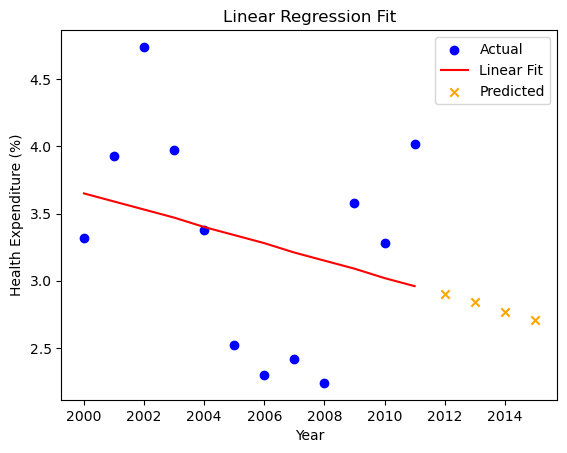

R² Score: 0.081614651750613
Mean Squared Error: 0.5379416666666667
The scores indicate that linnear regression is a bad fit for predicting values, as the trend is not linear.
Al countries from the Northern African sub-region has a clear up-trend in health expenditure percentage. A polynomial regression will be a better fit to predict values.


In [660]:
libya_data = life_exp_clean_2[life_exp_clean_2['country'] == 'Libya']
recorded_data = libya_data.dropna(subset=['health_expenditure_percentage'])

recorded_years = recorded_data['year'].values.reshape(-1, 1)
recorded_hep_values = recorded_data['health_expenditure_percentage'].values
missing_years = np.arange(2012, 2016).reshape(-1, 1)

model = LinearRegression()
model.fit(recorded_years, recorded_hep_values)

missing_hep_values_predict = np.round(model.predict(missing_years), 2)
known_hep_values_predict = np.round(model.predict(recorded_years), 2)

plt.scatter(recorded_years, recorded_hep_values, color='blue', label='Actual')
plt.plot(recorded_years, known_hep_values_predict, color='red', label='Linear Fit')
plt.scatter(missing_years, missing_hep_values_predict, marker='x', color='orange', label= 'Predicted')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Health Expenditure (%)')
plt.title('Linear Regression Fit')
plt.show()

r2 = r2_score(list(recorded_hep_values), list(known_hep_values_predict))
mse = mean_squared_error(recorded_hep_values, known_hep_values_predict)

print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")
print('The scores indicate that linnear regression is a bad fit for predicting values, as the trend is not linear.')
print('Al countries from the Northern African sub-region has a clear up-trend in health expenditure percentage. A polynomial regression will be a better fit to predict values.')



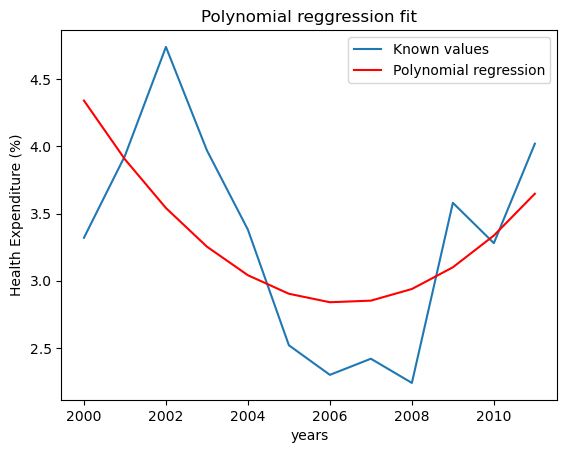

<Figure size 640x480 with 0 Axes>

In [661]:
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(recorded_years, recorded_hep_values)

poly_predict_known_values = poly_model.predict(recorded_years)
poly_predicted_values = poly_model.predict(missing_years)

plt.plot(recorded_years, recorded_hep_values, label = 'Known values')
plt.plot(recorded_years, poly_predict_known_values, color='Red', label = 'Polynomial regression')
plt.legend()
plt.xlabel('years')
plt.ylabel('Health Expenditure (%)')
plt.title('Polynomial reggression fit')
plt.show()
plt.clf()

print()

As the missing health expenditure percentage for Libya and Syria falls under the Not Missing at Random (NMAR) category, since it is the data of the later years which are missing, assumptions can be made that there are political reasons for not publishing the data. Assumptions can be made that the actual values could be negative (continues the down trend). Due to a crisis that affected the country and led to a scarcity of budgetary allocations. The crisis also had a significant impact on the deterioration of public services, including health services. 

Adding imputed values to Life Expectancy df

In [662]:
for year, value in zip(missing_years.flatten(), missing_hep_values_predict):
    life_exp_clean_2.loc[(life_exp_clean_2['year'] == year) & (life_exp_clean_2['country'] == 'Libya') , 'health_expenditure_percentage'] = value

hep_values_to_year = life_exp_clean_2[['year', 'health_expenditure_percentage']][life_exp_clean_2['country']== 'Libya'].sort_values('year', ascending=True)

#### Syrian Arab Republic 

R² Score: 0.8469566624416818
Mean Squared Error: 0.08730769230769232
The scores indicate that linnear regression is a good fit for predicting values, as the trend shows a strong linear relationship.
A good assumption could be that the data was withheld from the public due to political reasons


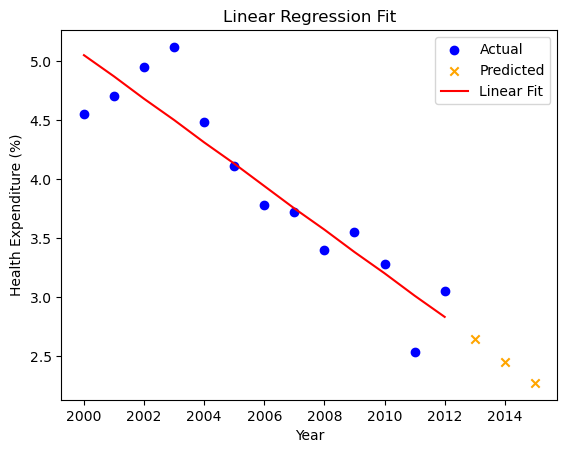

In [663]:
syria_data = life_exp_clean_2[life_exp_clean_2['country'] == 'Syrian Arab Republic']
recorded_data = syria_data.dropna(subset=['health_expenditure_percentage'])

recorded_years = recorded_data['year'].values.reshape(-1, 1)
recorded_hep_values = recorded_data['health_expenditure_percentage'].values
missing_years = np.arange(2013, 2016).reshape(-1, 1)

model = LinearRegression()
model.fit(recorded_years, recorded_hep_values)

missing_hep_values_predict = np.round(model.predict(missing_years), 2)
known_hep_values_predict = np.round(model.predict(recorded_years), 2)

r2 = r2_score(list(recorded_hep_values), list(known_hep_values_predict))
mse = mean_squared_error(recorded_hep_values, known_hep_values_predict)

print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")
print('The scores indicate that linnear regression is a good fit for predicting values, as the trend shows a strong linear relationship.')
print('A good assumption could be that the data was withheld from the public due to political reasons')

for year, value in zip(missing_years.flatten(), missing_hep_values_predict):
    life_exp_clean_2.loc[(life_exp_clean_2['year'] == year) & (life_exp_clean_2['country'] == 'Syrian Arab Republic') , 'health_expenditure_percentage'] = value

hep_values_to_year = life_exp_clean_2[['year', 'health_expenditure_percentage']][life_exp_clean_2['country']== 'Syrian Arab Republic'].sort_values('year', ascending=True)

plt.scatter(recorded_years, recorded_hep_values, color='blue', label='Actual')
plt.scatter(missing_years, missing_hep_values_predict, marker='x', color='orange', label= 'Predicted')
plt.plot(recorded_years, known_hep_values_predict, color='red', label='Linear Fit')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Health Expenditure (%)')
plt.title('Linear Regression Fit')
plt.show()

### Multiple Imputation by region

Health Expenditure Percentage values are calculated by imputation from all African region countries' data. Somalia is the only African country with missing health_expenditure_percentage values and the correlation between regions to health expenditure is much stronger than to that of sub-regions. 

#### Somalia

### Total Expenditure

In [664]:
unique_countries_na_te = np.unique(life_exp_clean_2['country'][life_exp_clean_2['total_expenditure'].isna()])
print(unique_countries_na_te)

['Afghanistan' 'Iraq' 'Libya' 'Montenegro' 'Somalia'
 'Syrian Arab Republic' 'Timor-Leste' 'Zimbabwe']


### Unemployment Total

In [665]:
unique_countries_na_ut = np.unique(life_exp_clean_2['country'][life_exp_clean_2['unemployment_total'].isna()])
print(unique_countries_na_ut)

['Antigua and Barbuda' 'Grenada' 'Kiribati'
 'Micronesia (Federated States of)' 'Seychelles']


# Creating csv files from tidied datasets for analysis

Creating csv file in cleaned_datasets folder of first cleaned dataset from life_exp_clean_2 with no missing values. Validity of data in columns - bmi, adult_mortality, under_five_deaths, mealses and hiv_aids still need to be checked in WHO and World Bank datasets and modified if values are incorrect. For now I will use this data for analysis and visualization.

In [666]:
life_exp_clean_2.to_csv("../Datasets/Cleaned_datasets/Life_expectancy_cleaned_1.csv")